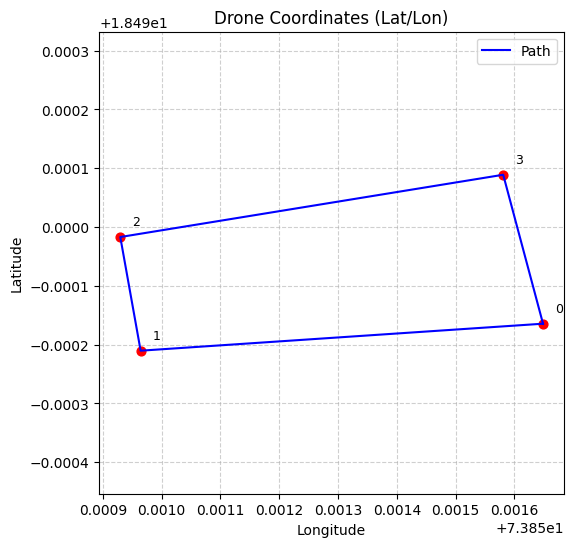

In [2]:
import matplotlib.pyplot as plt

lats = [18.4898357, 18.4897898, 18.4899831, 18.4900890]
lngs = [73.8516485, 73.8509642, 73.8509296, 73.8515808]

# --- Plot ---
plt.figure(figsize=(6,6))
plt.plot(lngs + [lngs[0]], lats + [lats[0]], color='blue', linewidth=1.5, label='Path')
plt.scatter(lngs, lats, color='red', s=40)

# Add annotations for each point
for i, (lat, lon) in enumerate(zip(lats, lngs)):
    plt.text(lon + 0.00002, lat + 0.00002, f"{i}", fontsize=9, color='black')

plt.title("Drone Coordinates (Lat/Lon)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()


In [3]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import transform
import pyproj
import math


points = [
        
        (18.4899831, 73.8509296),
        (18.4900890, 73.8515808),
        (18.4898357, 73.8516485), 
        (18.4897898, 73.8509642)
    ]

def truncate_number(num, decimals=7):
  
    factor = 10 ** decimals
    truncated = math.trunc(num * factor) / factor
    return truncated


def initial_coords(points):

    
   
    
    poly = Polygon([(lon, lat) for lat, lon in points])
    
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )

    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform
    
    poly_m = transform(project_to_m, poly)
    
    poly_inward_m = poly_m.buffer(-2)
    
    poly_inward = transform(project_to_deg, poly_inward_m)
    
    inward_coords = [(truncate_number(lat), truncate_number(lon)) for lon, lat in poly_inward.exterior.coords]
    inward_coords.pop()
 
    x, y = poly.exterior.xy
    xi, yi = poly_inward.exterior.xy

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'b-', marker='o', label='Original Polygon')
    plt.plot(xi, yi, 'r-', marker='o', label='Inward (2m) Polygon')
    plt.legend()
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Polygon and 2m Inward Offset')
    plt.show()


    return inward_coords
 
 


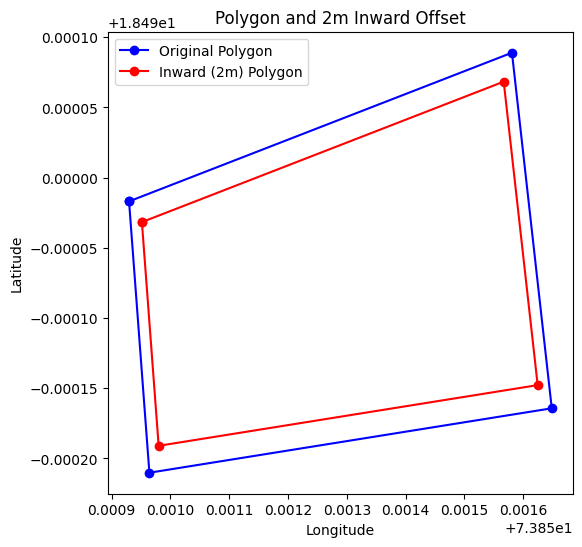

[(18.489836, 73.850975), (18.489836, 73.8513833), (18.4898631, 73.8516215), (18.4898631, 73.8509702), (18.4898902, 73.8509653), (18.4898902, 73.8516143), (18.4899173, 73.851607), (18.4899173, 73.8509605), (18.4899444, 73.8509556), (18.4899444, 73.8515998), (18.4899715, 73.8515925), (18.4899715, 73.8509712), (18.4899986, 73.8511379), (18.4899986, 73.8515853), (18.4900257, 73.851578), (18.4900257, 73.8513047), (18.4900528, 73.8514715), (18.4900528, 73.8515708)]


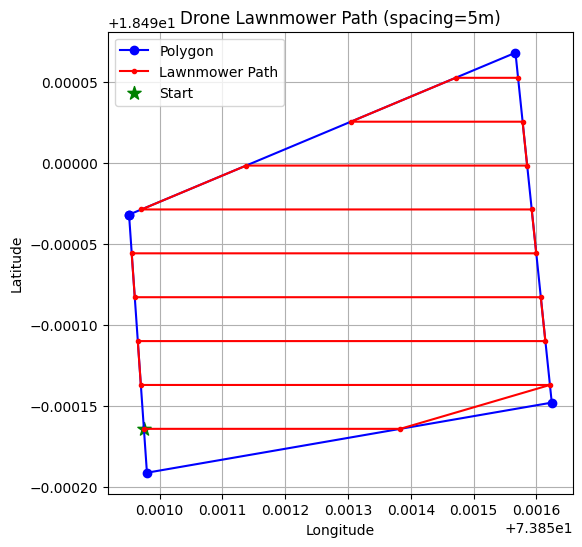

In [4]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj
import numpy as np
import math

inward_coords = initial_coords(points)



def generate_lawnmower_path(polygon_coords, spacing):
    poly = Polygon([(lon, lat) for lat, lon in polygon_coords])

    # Projection to meters
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    poly_m = transform(project_to_m, poly)

    # Horizontal sweep lines
    minx, miny, maxx, maxy = poly_m.bounds
    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    # Clip lines to polygon
    segments = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        if clipped.geom_type == 'LineString':
            segments.append(list(clipped.coords))
        elif clipped.geom_type == 'MultiLineString':
            for seg in clipped.geoms:
                segments.append(list(seg.coords))

    # Boustrophedon ordering
    path = []
    for i, seg in enumerate(segments):
        if i % 2 == 0:
            path.extend(seg)
        else:
            path.extend(seg[::-1])

    # Convert back to lat/lon
    path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path]
    return [(truncate_number(pt.y), truncate_number(pt.x)) for pt in path_latlon]

# --- Generate path ---
lawn_path = generate_lawnmower_path(inward_coords, spacing=3)  # spacing in meters



print(lawn_path)

# --- Plot polygon + path ---
poly_lat, poly_lon = zip(*inward_coords)
path_lat, path_lon = zip(*lawn_path)
plt.figure(figsize=(6, 6))
# Plot the polygon
plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), 'b-', marker='o', label='Polygon')
# Plot the lawnmower path
plt.plot(path_lon, path_lat, 'r-', marker='.', label='Lawnmower Path')
# Highlight the starting location
plt.scatter(path_lon[0], path_lat[0], c='green', s=100, marker='*', label='Start')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Drone Lawnmower Path (spacing={5}m)')
plt.legend()
plt.grid(True)
plt.show()


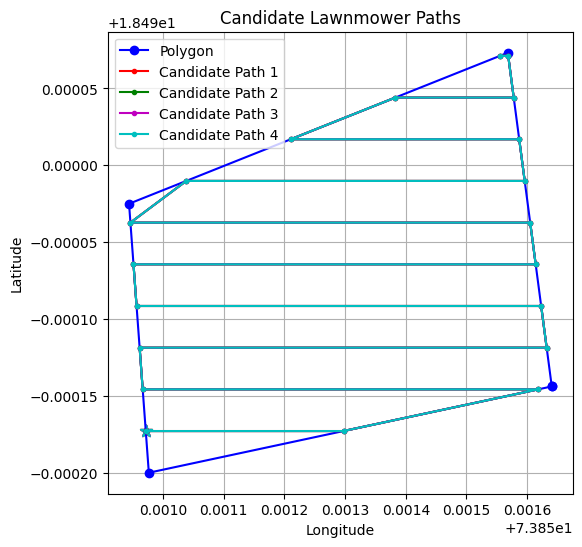

In [5]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj
import numpy as np

def generate_candidate_lawnmower_paths(polygon_coords, spacing=2.0, origin=None):
    """
    Generate 4 lawnmower paths starting from each polygon vertex.
    Align sweeps along the longer side of the polygon.
    
    Returns:
        paths: list of 4 lists of (lat, lon) tuples
    """
    poly = Polygon([(lon, lat) for lat, lon in polygon_coords])

    # Project to meters
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    poly_m = transform(project_to_m, poly)

    # Compute polygon dimensions to determine sweep direction
    minx, miny, maxx, maxy = poly_m.bounds
    width = maxx - minx
    height = maxy - miny

    sweep_horizontal = width >= height  # True if sweeps should be horizontal

    paths = []

    # Try 4 starting points (polygon vertices)
    for start_idx in range(len(polygon_coords)):
        # Reorder polygon coordinates to start from current vertex
        reordered_coords = polygon_coords[start_idx:] + polygon_coords[:start_idx]
        poly_m_reordered = Polygon([(lon, lat) for lat, lon in reordered_coords])
        poly_m_proj = transform(project_to_m, poly_m_reordered)

        # Generate sweep lines along longer side
        lines = []
        if sweep_horizontal:
            y = poly_m_proj.bounds[1]  # miny
            while y <= poly_m_proj.bounds[3]:
                lines.append(LineString([(poly_m_proj.bounds[0], y), (poly_m_proj.bounds[2], y)]))
                y += spacing
        else:  # vertical sweeps
            x = poly_m_proj.bounds[0]  # minx
            while x <= poly_m_proj.bounds[2]:
                lines.append(LineString([(x, poly_m_proj.bounds[1]), (x, poly_m_proj.bounds[3])]))
                x += spacing

        # Clip lines to polygon
        segments = []
        for i, line in enumerate(lines):
            clipped = line.intersection(poly_m_proj)
            if clipped.is_empty:
                continue
            if clipped.geom_type == 'LineString':
                segments.append(list(clipped.coords))
            elif clipped.geom_type == 'MultiLineString':
                for seg in clipped.geoms:
                    segments.append(list(seg.coords))

        # Boustrophedon ordering
        path_m = []
        for i, seg in enumerate(segments):
            if i % 2 == 0:
                path_m.extend(seg)
            else:
                path_m.extend(seg[::-1])

        # Convert back to lat/lon
        path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path_m]
        path_latlon = [(pt.y, pt.x) for pt in path_latlon]
        paths.append(path_latlon)

    # Optional: choose closest start to origin
    if origin:
        def distance_to_origin(path):
            lat, lon = path[0]
            return np.sqrt((lat - origin[0])**2 + (lon - origin[1])**2)
        paths.sort(key=distance_to_origin)

    return paths

# --- Example usage ---
origin = (18.4898567, 73.8510503)  # drone origin
inward_coords = [
    (18.4898562, 73.8516405),
    (18.4898001, 73.8509768),
    (18.4899750, 73.8509442),
    (18.4900732, 73.8515681)
]

candidate_paths = generate_candidate_lawnmower_paths(inward_coords, spacing=3, origin=origin)

# Plot
plt.figure(figsize=(6, 6))
poly_lat, poly_lon = zip(*inward_coords)
plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), 'b-', marker='o', label='Polygon')

colors = ['r', 'g', 'm', 'c']
for i, path in enumerate(candidate_paths):
    path_lat, path_lon = zip(*path)
    plt.plot(path_lon, path_lat, '-', marker='.', color=colors[i], label=f'Candidate Path {i+1}')
    plt.scatter(path_lon[0], path_lat[0], s=80, marker='*', color=colors[i])  # starting point

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Candidate Lawnmower Paths')
plt.legend()
plt.grid(True)
plt.show()


Inward Polygon Coords:
[(18.4898522, 73.8516245), (18.4898089, 73.8509799), (18.4899683, 73.8509514), (18.4900683, 73.8515667)]

Lawnmower Path Coords:
[(18.489854, 73.8509718), (18.489854, 73.8516239), (18.4898992, 73.8516119), (18.4898992, 73.8509637), (18.4899444, 73.8509556), (18.4899444, 73.8515998), (18.4899895, 73.8515877), (18.4899895, 73.8510824), (18.4900347, 73.8513603), (18.4900347, 73.8515756)]


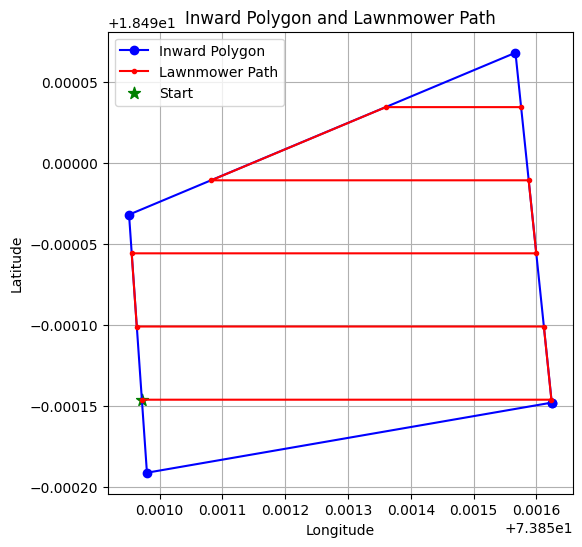

In [10]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj
import math

def generate_inward_lawnmower_path(points, spacing=5, buffer_m=2, decimals=7):
    """
    points: list of (lat, lon) tuples defining polygon
    spacing: distance between lawnmower lines in meters
    buffer_m: inward buffer distance in meters
    decimals: number of decimal places for output coords
    Returns: list of (lat, lon) tuples representing the lawnmower path
    """

    def truncate_number(num, decimals=7):
        factor = 10 ** decimals
        return math.trunc(num * factor) / factor

    # --- Build original polygon ---
    poly = Polygon([(lon, lat) for lat, lon in points])

    # --- Projection to meters ---
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    # --- Offset polygon inward ---
    poly_m = transform(project_to_m, poly)
    poly_inward_m = poly_m.buffer(-buffer_m)
    poly_inward = transform(project_to_deg, poly_inward_m)
    inward_coords = [(truncate_number(lat, decimals), truncate_number(lon, decimals)) 
                     for lon, lat in poly_inward.exterior.coords]
    inward_coords.pop()  # remove duplicate last point

    # --- Generate lawnmower path ---
    poly_m = transform(project_to_m, Polygon([(lon, lat) for lat, lon in inward_coords]))
    minx, miny, maxx, maxy = poly_m.bounds
    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    segments = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        if clipped.geom_type == 'LineString':
            segments.append(list(clipped.coords))
        elif clipped.geom_type == 'MultiLineString':
            for seg in clipped.geoms:
                segments.append(list(seg.coords))

    path = []
    for i, seg in enumerate(segments):
        path.extend(seg if i % 2 == 0 else seg[::-1])

    path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path]
    lawnmower_path = [(truncate_number(pt.y, decimals), truncate_number(pt.x, decimals)) for pt in path_latlon]

    return inward_coords, lawnmower_path


# --- Example usage ---
points = [
    (18.4898357, 73.8516485), 
    (18.4897898, 73.8509642),
    (18.4899831, 73.8509296),
    (18.4900890, 73.8515808)
    
]

inward_coords, lawn_path = generate_inward_lawnmower_path(points, spacing=5)

print("Inward Polygon Coords:")
print(inward_coords)
print("\nLawnmower Path Coords:")
print(lawn_path)

# --- Optional Plot ---
poly_lat, poly_lon = zip(*inward_coords)
path_lat, path_lon = zip(*lawn_path)

plt.figure(figsize=(6,6))
plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), 'b-', marker='o', label='Inward Polygon')
plt.plot(path_lon, path_lat, 'r-', marker='.', label='Lawnmower Path')
plt.scatter(path_lon[0], path_lat[0], s=80, marker='*', color='green', label='Start')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Inward Polygon and Lawnmower P4ath')
plt.legend()
plt.grid(True)
plt.show()


Inward Polygon Coords:
[(18.4898522, 73.8516245), (18.4898089, 73.8509799), (18.4899683, 73.8509514), (18.4900683, 73.8515667)]

Lawnmower Path Coords:
[(18.489854, 73.8509718), (18.489854, 73.8516239), (18.4898992, 73.8516119), (18.4898992, 73.8509637), (18.4899444, 73.8509556), (18.4899444, 73.8515998), (18.4899895, 73.8515877), (18.4899895, 73.8510824), (18.4900347, 73.8513603), (18.4900347, 73.8515756)]

Centroid Coordinate:
(18.4899259, 73.8512971)


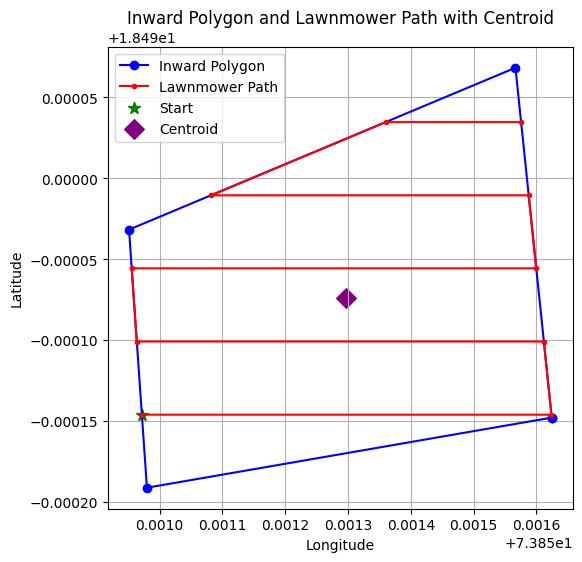

In [11]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj
import math

def generate_inward_lawnmower_path(points, spacing=5, buffer_m=2, decimals=7):
    """
    points: list of (lat, lon) tuples defining polygon
    spacing: distance between lawnmower lines in meters
    buffer_m: inward buffer distance in meters
    decimals: number of decimal places for output coords
    Returns: list of (lat, lon) tuples representing the lawnmower path
    """

    def truncate_number(num, decimals=7):
        factor = 10 ** decimals
        return math.trunc(num * factor) / factor

    # --- Build original polygon ---
    poly = Polygon([(lon, lat) for lat, lon in points])

    # --- Projection to meters ---
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    # --- Offset polygon inward ---
    poly_m = transform(project_to_m, poly)
    poly_inward_m = poly_m.buffer(-buffer_m)
    poly_inward = transform(project_to_deg, poly_inward_m)
    inward_coords = [(truncate_number(lat, decimals), truncate_number(lon, decimals)) 
                     for lon, lat in poly_inward.exterior.coords]
    inward_coords.pop()  # remove duplicate last point

    # --- Generate lawnmower path ---
    poly_m = transform(project_to_m, Polygon([(lon, lat) for lat, lon in inward_coords]))
    minx, miny, maxx, maxy = poly_m.bounds
    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    segments = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        if clipped.geom_type == 'LineString':
            segments.append(list(clipped.coords))
        elif clipped.geom_type == 'MultiLineString':
            for seg in clipped.geoms:
                segments.append(list(seg.coords))

    path = []
    for i, seg in enumerate(segments):
        path.extend(seg if i % 2 == 0 else seg[::-1])

    path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path]
    lawnmower_path = [(truncate_number(pt.y, decimals), truncate_number(pt.x, decimals)) for pt in path_latlon]

    # --- Calculate Centroid ---
    centroid = poly_inward.centroid
    centroid_latlon = (truncate_number(centroid.y, decimals), truncate_number(centroid.x, decimals))

    return inward_coords, lawnmower_path, centroid_latlon

def plot_lawnmower_path(inward_coords, lawn_path, centroid_coord):
    """
    Plots the inward polygon, lawnmower path, and marks the centroid.
    """
    poly_lat, poly_lon = zip(*inward_coords)
    path_lat, path_lon = zip(*lawn_path)

    plt.figure(figsize=(6,6))
    plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), 'b-', marker='o', label='Inward Polygon')
    plt.plot(path_lon, path_lat, 'r-', marker='.', label='Lawnmower Path')
    plt.scatter(path_lon[0], path_lat[0], s=80, marker='*', color='green', label='Start')
    
    # Mark the centroid location
    plt.scatter(centroid_coord[1], centroid_coord[0], s=100, marker='D', color='purple', label='Centroid')
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Inward Polygon and Lawnmower Path with Centroid')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Example usage ---
points = [
    (18.4898357, 73.8516485), 
    (18.4897898, 73.8509642),
    (18.4899831, 73.8509296),
    (18.4900890, 73.8515808)
]

inward_coords, lawn_path, centroid = generate_inward_lawnmower_path(points, spacing=5)

print("Inward Polygon Coords:")
print(inward_coords)
print("\nLawnmower Path Coords:")
print(lawn_path)
print("\nCentroid Coordinate:")
print(centroid)

# Plot the result
plot_lawnmower_path(inward_coords, lawn_path, centroid)


Centroid: (12.8580332, 77.4413463)
Square Corners: [(12.8580376, 77.4413416), (12.8580376, 77.4413509), (12.8580287, 77.4413509), (12.8580287, 77.4413416)]


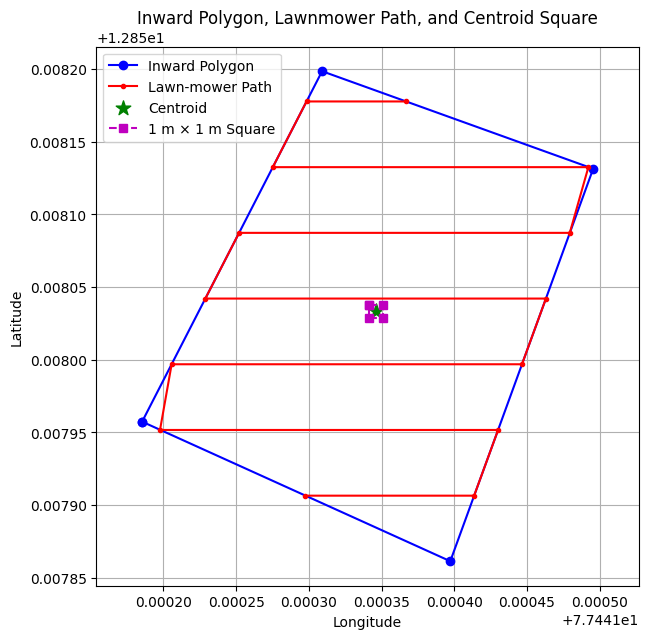

In [10]:
import math
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj


# --- Helper function ---
def truncate_number(num, decimals=7):
    factor = 10 ** decimals
    return math.trunc(num * factor) / factor


# --- Lawn-mower path generator ---
def generate_inward_lawnmower_path(points, spacing=5, buffer_m=2, decimals=7):
    """Generate inward offset polygon and lawn-mower pattern path."""

    def calculate_centroid(inward_coords):
        poly_inward = Polygon([(lon, lat) for lat, lon in inward_coords])
        centroid = poly_inward.centroid
        return (truncate_number(centroid.y, 7), truncate_number(centroid.x, 7))

    # Original polygon
    poly = Polygon([(lon, lat) for lat, lon in points])

    # Projection setup
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    # Inward offset polygon
    poly_m = transform(project_to_m, poly)
    poly_inward_m = poly_m.buffer(-buffer_m)
    poly_inward = transform(project_to_deg, poly_inward_m)
    inward_coords = [
        (truncate_number(lat, decimals), truncate_number(lon, decimals))
        for lon, lat in poly_inward.exterior.coords
    ]
    inward_coords.pop()  # remove duplicate last point

    centroid = calculate_centroid(inward_coords)

    # Lawn-mower path lines
    poly_m = transform(project_to_m, Polygon([(lon, lat) for lat, lon in inward_coords]))
    minx, miny, maxx, maxy = poly_m.bounds
    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    # Clip lines to polygon
    segments = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        if clipped.geom_type == "LineString":
            segments.append(list(clipped.coords))
        elif clipped.geom_type == "MultiLineString":
            for seg in clipped.geoms:
                segments.append(list(seg.coords))

    # Combine into single path (zig-zag)
    path = []
    for i, seg in enumerate(segments):
        path.extend(seg if i % 2 == 0 else seg[::-1])

    # Convert back to lat/lon
    path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path]
    lawnmower_path = [
        (truncate_number(pt.y, decimals), truncate_number(pt.x, decimals)) for pt in path_latlon
    ]

    return inward_coords, lawnmower_path, centroid


# --- 1 m square around centroid ---
def square_around_centroid(centroid, side_m=1.0):
    """Return 4 GPS points forming a square centered at centroid."""
    lat_c, lon_c = centroid
    half = side_m / 2.0

    dlat = half / 111320.0
    dlon = half / (111320.0 * math.cos(math.radians(lat_c)))

    top_left = (truncate_number(lat_c + dlat), truncate_number(lon_c - dlon))
    top_right = (truncate_number(lat_c + dlat), truncate_number(lon_c + dlon))
    bottom_right = (truncate_number(lat_c - dlat), truncate_number(lon_c + dlon))
    bottom_left = (truncate_number(lat_c - dlat), truncate_number(lon_c - dlon))

    return [top_left, top_right, bottom_right, bottom_left]


# --- Example polygon (GPS points) ---
points = [
    (12.8579488, 77.4411603),
    (12.8582210, 77.4413001),
    (12.8581422, 77.4415192),
    (12.8578366, 77.4414079),
]
# --- Run computations ---
inward_coords, lawn_path, centroid = generate_inward_lawnmower_path(points)
square_coords = square_around_centroid(centroid, side_m=1.0)

print("Centroid:", centroid)
print("Square Corners:", square_coords)


# --- Plot everything ---
plt.figure(figsize=(7, 7))

# Plot inward polygon
poly_lat, poly_lon = zip(*inward_coords)
plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), "b-", marker="o", label="Inward Polygon")

# Plot lawn-mower path
path_lat, path_lon = zip(*lawn_path)
plt.plot(path_lon, path_lat, "r-", marker=".", label="Lawn-mower Path")

# Plot centroid
plt.scatter(centroid[1], centroid[0], s=120, color="green", marker="*", label="Centroid")

# Plot 1 m square
sq_lat, sq_lon = zip(*square_coords + [square_coords[0]])
plt.plot(sq_lon, sq_lat, "m--", marker="s", label="1 m × 1 m Square")

# Labels & grid
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Inward Polygon, Lawnmower Path, and Centroid Square")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


Centroid: (12.5128499, 77.2628499)
Square Corners: [(12.5128543, 77.2628452), (12.5128543, 77.2628545), (12.5128454, 77.2628545), (12.5128454, 77.2628452)]


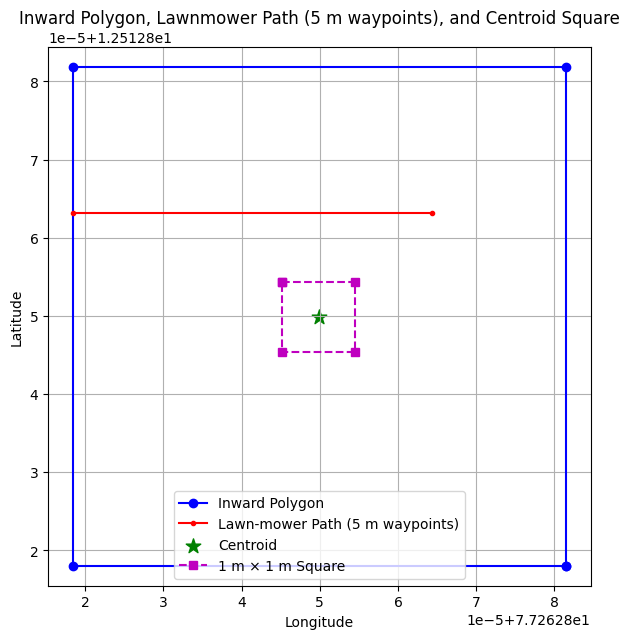

In [2]:
import math
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj


# --- Helper function ---
def truncate_number(num, decimals=7):
    factor = 10 ** decimals
    return math.trunc(num * factor) / factor


# --- Densify path every X meters ---
def densify_path(path, spacing_m=5):
    """Insert intermediate waypoints every `spacing_m` meters along the path."""
    if len(path) < 2:
        return path

    # Local projection centered on first point
    proj_latlon = pyproj.CRS("EPSG:4326")
    lat0, lon0 = path[0]
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={lat0} +lon_0={lon0} +units=m +datum=WGS84"
    )

    project_to_m = pyproj.Transformer.from_crs(
        proj_latlon, proj_local, always_xy=True
    ).transform
    project_to_deg = pyproj.Transformer.from_crs(
        proj_local, proj_latlon, always_xy=True
    ).transform

    # Convert path to meters
    line_m = LineString([project_to_m(lon, lat) for lat, lon in path])
    total_len = line_m.length

    # Sample points along the path
    new_points = []
    d = 0
    while d <= total_len:
        x, y = line_m.interpolate(d).coords[0]
        lon, lat = project_to_deg(x, y)
        new_points.append((
            truncate_number(lat, 7),
            truncate_number(lon, 7)
        ))
        d += spacing_m

    return new_points


# --- Lawn-mower path generator ---
def generate_inward_lawnmower_path(points, spacing=5, buffer_m=2, decimals=7):
    """Generate inward offset polygon and lawn-mower pattern path."""

    def calculate_centroid(inward_coords):
        poly_inward = Polygon([(lon, lat) for lat, lon in inward_coords])
        centroid = poly_inward.centroid
        return (truncate_number(centroid.y, 7), truncate_number(centroid.x, 7))

    # Original polygon
    poly = Polygon([(lon, lat) for lat, lon in points])

    # Projection setup
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    project_to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    project_to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    # Inward offset polygon
    poly_m = transform(project_to_m, poly)
    poly_inward_m = poly_m.buffer(-buffer_m)
    poly_inward = transform(project_to_deg, poly_inward_m)
    inward_coords = [
        (truncate_number(lat, decimals), truncate_number(lon, decimals))
        for lon, lat in poly_inward.exterior.coords
    ]
    inward_coords.pop()  # remove duplicate last point

    centroid = calculate_centroid(inward_coords)

    # Lawn-mower path lines
    poly_m = transform(project_to_m, Polygon([(lon, lat) for lat, lon in inward_coords]))
    minx, miny, maxx, maxy = poly_m.bounds
    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    # Clip lines to polygon
    segments = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        if clipped.geom_type == "LineString":
            segments.append(list(clipped.coords))
        elif clipped.geom_type == "MultiLineString":
            for seg in clipped.geoms:
                segments.append(list(seg.coords))

    # Combine into single path (zig-zag)
    path = []
    for i, seg in enumerate(segments):
        path.extend(seg if i % 2 == 0 else seg[::-1])

    # Convert back to lat/lon
    path_latlon = [transform(project_to_deg, Point(x, y)) for x, y in path]
    lawnmower_path = [
        (truncate_number(pt.y, decimals), truncate_number(pt.x, decimals)) for pt in path_latlon
    ]

    return inward_coords, lawnmower_path, centroid


# --- 1 m square around centroid ---
def square_around_centroid(centroid, side_m=1.0):
    lat_c, lon_c = centroid
    half = side_m / 2.0

    dlat = half / 111320.0
    dlon = half / (111320.0 * math.cos(math.radians(lat_c)))

    top_left = (truncate_number(lat_c + dlat), truncate_number(lon_c - dlon))
    top_right = (truncate_number(lat_c + dlat), truncate_number(lon_c + dlon))
    bottom_right = (truncate_number(lat_c - dlat), truncate_number(lon_c + dlon))
    bottom_left = (truncate_number(lat_c - dlat), truncate_number(lon_c - dlon))

    return [top_left, top_right, bottom_right, bottom_left]


# --- Example polygon ---
points = [
    (12.5128000, 77.2629000),
    (12.5129000, 77.2629000),
    (12.5129000, 77.2628000),
    (12.5128000, 77.2628000),
]

# --- Run computations ---
inward_coords, lawn_path, centroid = generate_inward_lawnmower_path(points)

# 👉 Densify lawn mower path every 5 m
lawn_path = densify_path(lawn_path, spacing_m=5)

square_coords = square_around_centroid(centroid, side_m=1.0)

print("Centroid:", centroid)
print("Square Corners:", square_coords)


# --- Plot everything ---
plt.figure(figsize=(7, 7))

# Plot inward polygon
poly_lat, poly_lon = zip(*inward_coords)
plt.plot(poly_lon + (poly_lon[0],), poly_lat + (poly_lat[0],), "b-", marker="o", label="Inward Polygon")

# Plot densified lawn-mower path
path_lat, path_lon = zip(*lawn_path)
plt.plot(path_lon, path_lat, "r-", marker=".", label="Lawn-mower Path (5 m waypoints)")

# Plot centroid
plt.scatter(centroid[1], centroid[0], s=120, color="green", marker="*", label="Centroid")

# Plot 1 m square
sq_lat, sq_lon = zip(*square_coords + [square_coords[0]])
plt.plot(sq_lon, sq_lat, "m--", marker="s", label="1 m × 1 m Square")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Inward Polygon, Lawnmower Path (5 m waypoints), and Centroid Square")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


[(12.8581776, 77.4413297), (12.8581745, 77.4413752), (12.8581589, 77.4414185), (12.8581433, 77.4414617), (12.8581324, 77.4414787), (12.8581324, 77.4414327), (12.8581324, 77.4413866), (12.8581324, 77.4413405), (12.8581324, 77.4412945), (12.8581089, 77.4412631), (12.8580872, 77.4412732), (12.8580872, 77.4413192), (12.8580872, 77.4413653), (12.8580872, 77.4414114), (12.8580872, 77.4414574), (12.8580649, 77.4414714), (12.858042, 77.4414418), (12.858042, 77.4413958), (12.858042, 77.4413497), (12.858042, 77.4413037), (12.858042, 77.4412576), (12.8580269, 77.441221), (12.8579968, 77.4412173), (12.8579968, 77.4412633), (12.8579968, 77.4413094), (12.8579968, 77.4413554), (12.8579968, 77.4414015), (12.8579958, 77.4414462), (12.8579532, 77.4414308), (12.8579516, 77.4413859), (12.8579516, 77.4413398), (12.8579516, 77.4412938), (12.8579516, 77.4412477), (12.8579516, 77.4412016), (12.8579343, 77.4412357), (12.8579154, 77.4412775), (12.8579064, 77.4413215), (12.8579064, 77.4413676), (12.8579063, 77.4

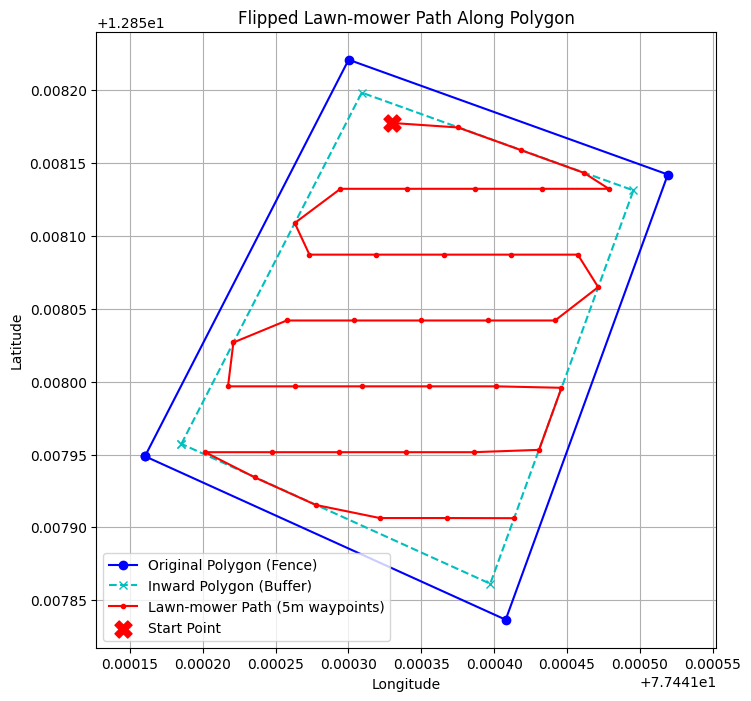

In [24]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import transform
import pyproj
import math

points = [
    (12.8579488, 77.4411603),
    (12.8582210, 77.4413001),
    (12.8581422, 77.4415192),
    (12.8578366, 77.4414079),
]

def generate_lawnmower_with_5m_spacing(points, spacing=10, buffer_m=2, decimals=7, waypoint_spacing=5):
    def truncate(num):
        factor = 10 ** decimals
        return math.trunc(num * factor) / factor

    poly = Polygon([(lon, lat) for lat, lon in points])
    proj_latlon = pyproj.CRS("EPSG:4326")
    proj_local = pyproj.CRS.from_proj4(
        f"+proj=tmerc +lat_0={poly.centroid.y} +lon_0={poly.centroid.x} +units=m +datum=WGS84"
    )
    to_m = pyproj.Transformer.from_crs(proj_latlon, proj_local, always_xy=True).transform
    to_deg = pyproj.Transformer.from_crs(proj_local, proj_latlon, always_xy=True).transform

    poly_m = transform(to_m, poly)
    poly_inward_m = poly_m.buffer(-buffer_m)
    poly_inward = transform(to_deg, poly_inward_m)
    inward_coords = [(truncate(lat), truncate(lon)) for lon, lat in poly_inward.exterior.coords[:-1]]

    poly_m = transform(to_m, Polygon([(lon, lat) for lat, lon in inward_coords]))
    minx, miny, maxx, maxy = poly_m.bounds

    lines = []
    y = miny
    while y <= maxy:
        lines.append(LineString([(minx, y), (maxx, y)]))
        y += spacing

    path_m = []
    for i, line in enumerate(lines):
        clipped = line.intersection(poly_m)
        if clipped.is_empty:
            continue
        segs = []
        if clipped.geom_type == "LineString":
            segs = [clipped]
        elif clipped.geom_type == "MultiLineString":
            segs = list(clipped.geoms)
        for seg in segs:
            coords = list(seg.coords)
            if i % 2 == 1:
                coords.reverse()
            path_m.extend(coords)

    path_latlon = [transform(to_deg, Point(x, y)) for x, y in path_m]
    path = [(truncate(pt.y), truncate(pt.x)) for pt in path_latlon]

    if len(path) > 1:
        lat0, lon0 = path[0]
        proj_local2 = pyproj.CRS.from_proj4(
            f"+proj=tmerc +lat_0={lat0} +lon_0={lon0} +units=m +datum=WGS84"
        )
        to_m2 = pyproj.Transformer.from_crs(proj_latlon, proj_local2, always_xy=True).transform
        to_deg2 = pyproj.Transformer.from_crs(proj_local2, proj_latlon, always_xy=True).transform

        line_m2 = LineString([to_m2(lon, lat) for lat, lon in path])
        total_len = line_m2.length

        dense = []
        d = 0
        while d <= total_len:
            x, y = line_m2.interpolate(d).coords[0]
            lon, lat = to_deg2(x, y)
            dense.append((truncate(lat), truncate(lon)))
            d += waypoint_spacing

        path = dense

    # Flip path
    path.reverse()

    return inward_coords, path

# -----------------------------
# Generate paths
# -----------------------------
inward_coords, lawn_path = generate_lawnmower_with_5m_spacing(points, spacing=5, buffer_m=2, waypoint_spacing=5)
print(lawn_path)

# -----------------------------
# Plot everything
# -----------------------------
plt.figure(figsize=(8, 8))

# Original polygon (fence)
poly_lat, poly_lon = zip(*points + [points[0]])
plt.plot(poly_lon, poly_lat, "b-", marker="o", label="Original Polygon (Fence)")

# Inward polygon
in_lat, in_lon = zip(*inward_coords + [inward_coords[0]])
plt.plot(in_lon, in_lat, "c--", marker="x", label="Inward Polygon (Buffer)")

# Lawn-mower path
path_lat, path_lon = zip(*lawn_path)
plt.plot(path_lon, path_lat, "r.-", label="Lawn-mower Path (5m waypoints)")

# Mark start point with a red cross
start_lat, start_lon = lawn_path[0]
plt.scatter(start_lon, start_lat, s=150, color="red", marker="X", label="Start Point")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Flipped Lawn-mower Path Along Polygon")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


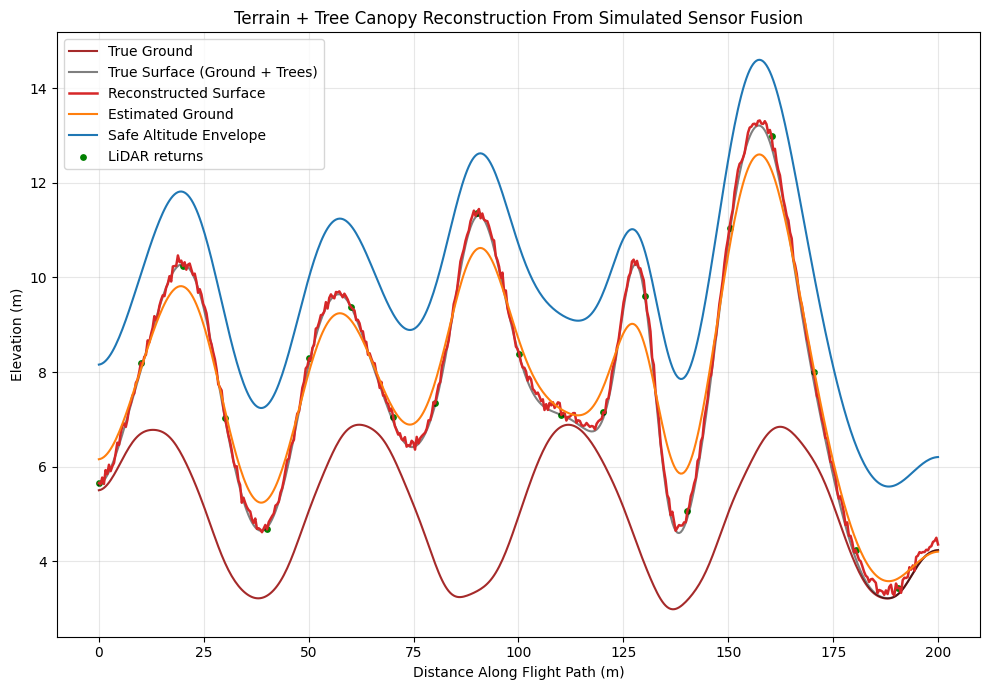

In [2]:
 

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
 

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
N = 500             # number of samples
hz = 12
np.random.seed(1)

# ---------------------------------------------------------
# 1. Generate Realistic Terrain (Perlin-like)
# ---------------------------------------------------------
base = np.sin(np.linspace(0, 8 * np.pi, N))
noise = np.random.normal(0, 0.3, N)
terrain = gaussian_filter1d(base + noise, sigma=8) * 2 + 5   # elevation 3–10 m

# ---------------------------------------------------------
# 2. Generate Tree Clusters
# ---------------------------------------------------------
tree_mask = np.zeros(N)
trees = []

num_clusters = 5
for _ in range(num_clusters):
    center = np.random.randint(50, N - 50)
    width = np.random.randint(10, 25)
    height = np.random.uniform(3, 8)  # canopy height above ground

    # smooth Gaussian tree canopy shape
    canopy = height * np.exp(-((np.arange(N) - center) ** 2) / (2 * (width ** 2)))

    tree_mask += canopy
    trees.append((center, width, height))

tree_mask = np.clip(tree_mask, 0, None)
true_surface = terrain + tree_mask

# ---------------------------------------------------------
# 3. Simulate Aircraft Flight Path
# ---------------------------------------------------------
x = np.linspace(0, 200, N)
true_altitude = 25 + 0.5 * np.sin(0.01 * x)   # above sea level

# ---------------------------------------------------------
# 4. Sensor Models
# ---------------------------------------------------------

# GPS corrected altitude (with drift + bias)
gps_bias = np.random.normal(0, 0.2)
gps_alt = true_altitude + gps_bias + np.sin(x * 0.002) * 0.3 + np.random.normal(0, 0.05, N)

# EKF altitude (slightly smoother, with small lag)
ekf_alt = gaussian_filter1d(gps_alt, sigma=3) + np.random.normal(0, 0.1, N)

# LiDAR measures distance to *nearest object* (terrain or tree)
true_lidar_range = true_altitude - true_surface
lidar_noise = np.random.normal(0, 0.05, N)
lidar = true_lidar_range + lidar_noise

# ---------------------------------------------------------
# 5. Fusion (GPS + EKF)
# ---------------------------------------------------------
fused_alt = 0.6 * gps_alt + 0.4 * ekf_alt

# reconstructed surface (terrain + trees)
reconstructed_surface = fused_alt - lidar

# ---------------------------------------------------------
# 6. Extract Ground vs Tree Estimates
# (simple filtering: ground = lower envelope of reconstructed surface)
# ---------------------------------------------------------
ground_est = gaussian_filter1d(reconstructed_surface, sigma=10)
tree_est = reconstructed_surface - ground_est
tree_est = np.clip(tree_est, 0, None)

# ---------------------------------------------------------
# 7. Safe flight corridor
# ---------------------------------------------------------
ground_clearance = 2.0
safe_alt = ground_est + ground_clearance

# ---------------------------------------------------------
# 8. Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))

plt.plot(x, terrain, label="True Ground", color="brown")
plt.plot(x, true_surface, label="True Surface (Ground + Trees)", color="black", alpha=0.5)
plt.plot(x, reconstructed_surface, label="Reconstructed Surface", color="tab:red", linewidth=1.8)

plt.plot(x, ground_est, label="Estimated Ground", color="tab:orange")
plt.plot(x, safe_alt, label="Safe Altitude Envelope", color="tab:blue")

plt.scatter(x[::25], fused_alt[::25] - lidar[::25],
            color="green", s=15, label="LiDAR returns")

plt.title("Terrain + Tree Canopy Reconstruction From Simulated Sensor Fusion")
plt.xlabel("Distance Along Flight Path (m)")
plt.ylabel("Elevation (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
